<a href="https://colab.research.google.com/github/sraymundo15/sraymundo15/blob/master/CHM343_Physical_Chemistry_Lab_1_Colab_Notebook_Sebastian_Raymundo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**ASU CHM 343 Physical Chemistry Lab '1' - Notebook**
##*Determination of Speed of Sound and Heat Capacity Ratios of Gases by Using Acoustic Interferometry*

September 9, 2025

**Sebastian Raymundo**, sraymun1@asu.edu

# **Abstract**

Acoustic interferometry was used to measure the speed of sound in natural gas (assumed to be primarily methane), air, and nitrogen by examining resonance frequencies within a resonance tube in Remote System 1 at ASU, accessed via *AnyDesk*. Air was used as a reference gas, with a known speed of sound of **344.89 ± 1.79 m/s** at 23 ± 2 °C for calibration. The acoustic data was extracted using *Audacity* audio software and analyzed using numpy, pandas, and SciPy on this CoLab notebook. Prior to experimentally calculating the speed of sound and other thermodynamic properties of each gas, a computational simulation was also run using *MolCalc* to estimate the expected thermodynamic properties of the gases. Afterwards, the speed of sound was calculated, finding it to be **434.53 ± 2.27 m/s** in natural gas, and **350.80 ± 1.81 m/s** in nitrogen. From these velocities, the adiabatic indexes for air, nitrogen, and natural gas were calculated, obtaining values of **1.397 ± 0.017**, **1.397 ± 0.017**, and **1.228 ± 0.015**, respectively. Additionally, the experimental heat capacities at constant volume were determined, yielding **20.96 ± 0.91 J/mol·K** for air, **20.94 ± 0.91 J/mol·K** for nitrogen, and **36.47 ± 2.44 J/mol·K** for natural gas.

# **Introduction**

The speed at which sound waves travel through air is commonly called the speed of sound <sup>[1]</sup>. However, the speed of sound can also be determined in different media through the use of acoustic interferometry and white noise <sup>[2, 3]</sup>, since the speed of sound depends on the thermodynamic properties of the medium in which it travels <sup>[4]</sup>. These properties include the medium's molecular density and its heat capacity. The heat capacity of a medium further involves the ways in which its molecules are excited in translational, rotational, and vibrational modes when energy is applied to the medium, as when sound waves travel through it. The relationship between the speed of sound and the medium's thermodynamic properties can be calculated through the following equation <sup>[1, 4]</sup>:

(1) $$c = \sqrt{\frac{K_s}{\rho}},$$

where

$$ K_s $$

is the modulus of bulk elasticity for gases (adiabatic bulk modulus), and

$$ \rho $$

is the density of the medium <sup>[4]</sup>.

Furthermore, equation (1) can be simplified to:

(2) $$c = \sqrt{\gamma\frac{RT}{M}}$$

when assuming ideal gases <sup>[1, 5]</sup>.


In equation (2),

$$ γ = C_p/C_v, $$ represents the adiabatic index, **R** is the universal gas constant, **T** is the absolute temperature, and **M** is the molar mass of the gas.

Monatomic gases typically have a higher adiabatic index (**γ**) since they have less degrees of freedom available for storing energy <sup>[6]</sup>. On the other hand, polyatomic gases have a lower **γ**, since they have more degrees of freedom for absorbing energy <sup>[6]</sup>. Thus, there exists an inverse relationship between the adiabiatic index of a gas and its heat capacity. Additionaly, this allows us to calculate the thermodynamic properties of a gas using acoustic interferometry.

In order to establish and test this relationship, we can use the following equation which relates the resonance frequencies in a closed tube to the speed of sound of the gas inside the tube:

(3) $$ L = \frac{n c}{2 f}, $$

where *f* is the resonance frequency and *n* is the harmonic number <sup>[1]</sup>. A plot can be created showing frequency vs harmonic number (*f* vs. *n*) where the slope is equal to *c/2L* <sup>[1]</sup>.

# **Methods**

Acoustic interferometry data was obtained using Remote System 1 at ASU, which was accessed using AnyDesk on September 01, 2025. Remote System 1 consisted of a 0.3 m tube connected to  a gas delivery system and a microphone on one end, and a speaker and gas outlet on the other end <sup>[1]</sup>.

<img src = "https://raw.githubusercontent.com/CHM343/Acoustic_Interferometer/3133505a394170317b9b03997ccf3fe983554689/ScreenShot/2025_09_03_remote_acoustic_System_1_AnyDesk_ScreenShot.png">*<sub>Screenshot of Remote System 1 at ASU used for the collection of acoustic interferometry data. Audacity is shown recording audio data on the left side of the screen while the remote system setup is shown on the right side of the screen. Image taken from the CHM343 Public Github repository.</sub>*

Using *Audacity* audio software, 20 seconds of white noise were generated. The white noise was then played through one end of the tube while exciting the selected gases and recording the audio on the other end. A 30 second purge of the system between recordings was used with each gas to ensure that the interferometer was recording the data relevant to each gas instead of a mixture of gases <sup>[7]</sup>.

Once the acoustic data was recorded, a Fourier transform <sup>[1]</sup> was performed on the recording of each gas using *Audacity* in order to visualize the resonance frequencies correctly and minimize error. The Fourier Transform data was exported in a .txt format and uploaded to a public Github repository to allow for easy access and analysis in this CoLab notebook.

Prior to analyzing the data, *[MolCalc](https://molcalc.org)* was used to run computational predictions of the thermodynamic properties of both nitrogen and natural gas (assuming methane). This data was used to validate if the experimental calculations performed in this CoLab notebook aligned with the predicted values.

The acoustic interferometry data was analyzed using numpy, pandas, SciPy, and matplotlib to find the resonance nodes of each gas and plot them in easy-to-understand graphs.

# **Set up Notebook Environment**

In [ ]:
# Python Libraries for display in Colab/Jupyter (Ipython)
from IPython import display
from IPython.display import Image

# Primary Python Libraries
import math
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy import stats
from scipy.stats import t
from tabulate import tabulate
import matplotlib.pyplot as plt

# Additional Matplotlib components to make custom plots
from matplotlib.offsetbox import AnnotationBbox
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import matplotlib.lines as lines
import matplotlib.ticker as ticker
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

# **Data/Results**

Computational Data for Nitrogen using *MolCalc* <sup>[8]</sup>. Speed of sound from *NIST Webbook* <sup>[9]</sup>.

In [ ]:
print("Nitrogen Computational Data")

data = [["Standard Enthalpy of Formation", 73.50, "kJ mol^-1"],
        ["Speed of Sound", 350.89, "m/s"],
        ["Adiabatic Index", 1.397]]
col_names = ["Ideal Gas at 298.13K", "   ", "   "]
print(tabulate(data, headers=col_names, tablefmt="fancy_grid"))

data = [["Translational", 6.20, "kJ mol^-1"],
        ["Rotational", 2.48, "kJ mol^-1"],
        ["Vibrational", 15.79, "kJ mol^-1"],
        ["Total", 24.47, "kJ mol^-1"]]
col_names = ["Enthalpy", "   ", "   "]
print(tabulate(data, headers=col_names, tablefmt="fancy_grid"))

data = [["Translational", 4.16, "J mol^-1 K^-1"],
        ["Rotational", 8.31, "J mol^-1 K^-1"],
        ["Vibrational", 0.00, "J mol^-1 K^-1"],
        ["Total", 12.47, "J mol^-1 K^-1"]]
col_names = ["Heat Capacity at Constant Volume", "    ","    "]
print(tabulate(data, headers=col_names, tablefmt="fancy_grid"))

data = [["Translational", 20.79, "J mol^-1 K^-1"],
        ["Rotational", 8.31, "J mol^-1 K^-1"],
        ["Vibrational", 0.00, "J mol^-1 K^-1"],
        ["Total", 29.10, "J mol^-1 K^-1"]]
col_names = ["Heat Capacity at Constant Pressure", "   ", "   "]
print(tabulate(data, headers=col_names, tablefmt="fancy_grid"))

Nitrogen Computational Data
╒════════════════════════════════╤═════════╤═══════════╕
│ Ideal Gas at 298.13K           │         │           │
╞════════════════════════════════╪═════════╪═══════════╡
│ Standard Enthalpy of Formation │  73.5   │ kJ mol^-1 │
├────────────────────────────────┼─────────┼───────────┤
│ Speed of Sound                 │ 350.89  │ m/s       │
├────────────────────────────────┼─────────┼───────────┤
│ Adiabatic Index                │   1.397 │           │
╘════════════════════════════════╧═════════╧═══════════╛
╒═══════════════╤═══════╤═══════════╕
│ Enthalpy      │       │           │
╞═══════════════╪═══════╪═══════════╡
│ Translational │  6.2  │ kJ mol^-1 │
├───────────────┼───────┼───────────┤
│ Rotational    │  2.48 │ kJ mol^-1 │
├───────────────┼───────┼───────────┤
│ Vibrational   │ 15.79 │ kJ mol^-1 │
├───────────────┼───────┼───────────┤
│ Total         │ 24.47 │ kJ mol^-1 │
╘═══════════════╧═══════╧═══════════╛
╒════════════════════════════════════╤═══

Computational Data for Natural Gas using *MolCalc* <sup>[10]</sup>. Speed of sound from *NIST Webbook* <sup>[11]</sup>.

In [ ]:
print("Natural Gas Computational Data (assuming Methane)")

data = [["Standard Enthalpy of Formation", -54.45, "kJ mol^-1"],
        ["Speed of Sound", 447.09, "m/s"],
        ["Adiabatic Index", 1.228]]
col_names = ["Ideal Gas at 298.13K", "   ", "   "]
print(tabulate(data, headers=col_names, tablefmt="fancy_grid"))

data = [["Translational", 6.20, "kJ mol^-1"],
        ["Rotational", 3.72, "kJ mol^-1"],
        ["Vibrational", 119.28, "kJ mol^-1"],
        ["Total", 129.20, "kJ mol^-1"]]
col_names = ["Enthalpy", "   ", "   "]
print(tabulate(data, headers=col_names, tablefmt="fancy_grid"))

data = [["Translational", 12.48, "J mol^-1 K^-1"],
        ["Rotational", 12.47, "J mol^-1 K^-1"],
        ["Vibrational", 2.25, "J mol^-1 K^-1"],
        ["Total", 27.20, "J mol^-1 K^-1"]]
col_names = ["Heat Capacity at Constant Volume", "    ","    "]
print(tabulate(data, headers=col_names, tablefmt="fancy_grid"))

data = [["Translational", 20.79, "J mol^-1 K^-1"],
        ["Rotational", 12.47, "J mol^-1 K^-1"],
        ["Vibrational", 2.25, "J mol^-1 K^-1"],
        ["Total", 35.51, "J mol^-1 K^-1"]]
col_names = ["Heat Capacity at Constant Pressure", "   ", "   "]
print(tabulate(data, headers=col_names, tablefmt="fancy_grid"))

Natural Gas Computational Data (assuming Methane)
╒════════════════════════════════╤═════════╤═══════════╕
│ Ideal Gas at 298.13K           │         │           │
╞════════════════════════════════╪═════════╪═══════════╡
│ Standard Enthalpy of Formation │ -54.45  │ kJ mol^-1 │
├────────────────────────────────┼─────────┼───────────┤
│ Speed of Sound                 │ 447.09  │ m/s       │
├────────────────────────────────┼─────────┼───────────┤
│ Adiabatic Index                │   1.228 │           │
╘════════════════════════════════╧═════════╧═══════════╛
╒═══════════════╤════════╤═══════════╕
│ Enthalpy      │        │           │
╞═══════════════╪════════╪═══════════╡
│ Translational │   6.2  │ kJ mol^-1 │
├───────────────┼────────┼───────────┤
│ Rotational    │   3.72 │ kJ mol^-1 │
├───────────────┼────────┼───────────┤
│ Vibrational   │ 119.28 │ kJ mol^-1 │
├───────────────┼────────┼───────────┤
│ Total         │ 129.2  │ kJ mol^-1 │
╘═══════════════╧════════╧═══════════╛
╒═══════

Read in Spectral Data from Github Public Repository

In [ ]:
# Read-in Audacity exported spectral data (and first line header label) from public sraymundo15 GitHub Repository using pandas.
# White Noise Spectrum
White_Noise_Spectrum = pd.read_table('https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/01_White_Noise_Spectrum.txt', sep = "\t" ,header=0)
# Air White Noise Spectrum
Air_Spectrum = pd.read_table('https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/01_Air_Spectrum.txt', sep = "\t" ,header=0)
# Nitrogen White Noise Spectrum
Nitrogen_Spectrum = pd.read_table('https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/01_Nitrogen_Spectrum.txt', sep = "\t" ,header=0)
# Natural Gas White Noise Spectrum
NG_Spectrum = pd.read_table('https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/01_Natural_Gas_Spectrum.txt', sep = "\t" ,header=0)

Visualize plot of Spectral Data

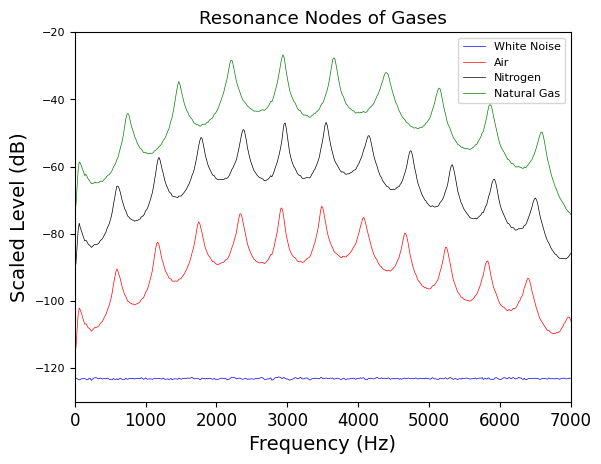

Figure 1: Plot showing the resonance nodes of each gas (air, nitrogen, and natural gas) and compared to a baseline of white noise spectral data.
Each resonance node can be easily identified as a peak in the spectral data of each gas


In [ ]:
# Initialize matplotlib subplot layout
fig, ax = plt.subplots()

# Set general font size
plt.rcParams['font.size'] = '11'

ax.plot(White_Noise_Spectrum['Frequency (Hz)'], White_Noise_Spectrum['Level (dB)']-90, linewidth=0.5, color = 'blue', label = 'White Noise')
ax.plot(Air_Spectrum['Frequency (Hz)'], Air_Spectrum['Level (dB)']-45, linewidth=0.5, color = 'red', label = 'Air')
ax.plot(Nitrogen_Spectrum['Frequency (Hz)'], Nitrogen_Spectrum['Level (dB)']-20, linewidth=0.5, color = 'black', label = 'Nitrogen')
ax.plot(NG_Spectrum['Frequency (Hz)'], NG_Spectrum['Level (dB)'], linewidth=0.5, color = 'green', label = 'Natural Gas')

# Plot x and y axis min/max limits for plot
plt.xlim(0, 7000)
plt.ylim(-130, -20)

# Label graph and axes
plt.title("Resonance Nodes of Gases")
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel("Scaled Level (dB)", fontsize=14)

# Plot legend and axes
ax.legend(loc = 'upper right', fontsize=8)
ax.get_yaxis().set_visible(True)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

# Display the Plot
plt.show()

print("Figure 1: Plot showing the resonance nodes of each gas (air, nitrogen, and natural gas) and compared to a baseline of white noise spectral data.")
print("Each resonance node can be easily identified as a peak in the spectral data of each gas")

Use the Python SciPy Library to Find Peaks in the Spectral Data and Display the Data in a Readable Table

In [ ]:
# Find peaks of each gas
Air_peaks = find_peaks(Air_Spectrum['Level (dB)'], distance = 25, prominence = 5)
Nitrogen_peaks = find_peaks(Nitrogen_Spectrum['Level (dB)'], distance = 25, prominence = 5)
NG_peaks = find_peaks(NG_Spectrum['Level (dB)'], distance = 25, prominence = 5)

Air_Frequency = Air_Spectrum['Frequency (Hz)']
Nitrogen_Frequency = Nitrogen_Spectrum['Frequency (Hz)']
NG_Frequency = NG_Spectrum['Frequency (Hz)']

Air_peak_list = Air_Frequency[Air_peaks[0]]
Nitrogen_peak_list = Nitrogen_Frequency[Nitrogen_peaks[0]]
NG_peak_list = NG_Frequency[NG_peaks[0]]

# Remove the first peak only if there is more than one peak
if len(Air_peak_list) > 1:
    Air_peak_list = Air_peak_list[1:]
if len(Nitrogen_peak_list) > 1:
    Nitrogen_peak_list = Nitrogen_peak_list[1:]
if len(NG_peak_list) > 1:
    NG_peak_list = NG_peak_list[1:]

Air_peak_array = np.array((round(Air_peak_list,2)))
Nitrogen_peak_array = np.array((round(Nitrogen_peak_list,2)))
NG_peak_array = np.array((round(NG_peak_list,2)))

Air_peaktable = pd.DataFrame(Air_peak_array, columns=["Frequency (Hz)"])
Nitrogen_peaktable = pd.DataFrame(Nitrogen_peak_array, columns=["Frequency (Hz)"])
NG_peaktable = pd.DataFrame(NG_peak_array, columns=["Frequency (Hz)"])

Air_peaktable['Node'] = np.arange(1, Air_peaktable.shape[0] + 1)
Nitrogen_peaktable['Node'] = np.arange(1, Nitrogen_peaktable.shape[0] + 1)
NG_peaktable['Node'] = np.arange(1, NG_peaktable.shape[0] + 1)

Air_peaktable = Air_peaktable.loc[:,['Node','Frequency (Hz)']]
Nitrogen_peaktable = Nitrogen_peaktable.loc[:,['Node','Frequency (Hz)']]
NG_peaktable = NG_peaktable.loc[:,['Node','Frequency (Hz)']]

# Display table with peak information for each gas
from IPython.display import display, HTML

html_tables = f"""
<table>
  <tr>
    <td style="vertical-align: top;">
      <h3>Air Peaks</h3>
      {Air_peaktable.to_html()}
    </td>
    <td style="vertical-align: top;">
      <h3>Nitrogen Peaks</h3>
      {Nitrogen_peaktable.to_html()}
    </td>
    <td style="vertical-align: top;">
      <h3>Natural Gas Peaks</h3>
      {NG_peaktable.to_html()}
    </td>
  </tr>
</table>
"""

display(HTML(html_tables))

print("Tables 1-3: Tables showing a list of nodes and their corresponding frequencies in Hertz for each of the gases selected (air, nitrogen, and natural gas).")
print("11 nodes were found for both air and nitrogen, while only 9 nodes were found for natural gas.")
print("The first node in each gas was eliminated due to inconsistent resonance and is not displayed in the corresponding table.")

,Node,Frequency (Hz)
0,1,593.75
1,2,1171.88
2,3,1750.00
3,4,2343.75
4,5,2921.88
5,6,3484.38
6,7,4078.12
7,8,4656.25
8,9,5234.38
9,10,5828.12


Tables 1-3: Tables showing a list of nodes and their corresponding frequencies in Hertz for each of the gases selected (air, nitrogen, and natural gas).
11 nodes were found for both air and nitrogen, while only 9 nodes were found for natural gas.
The first node in each gas was eliminated due to inconsistent resonance and is not displayed in the corresponding table.


Plot the combined Spectral Data and calculated peaks from SciPy

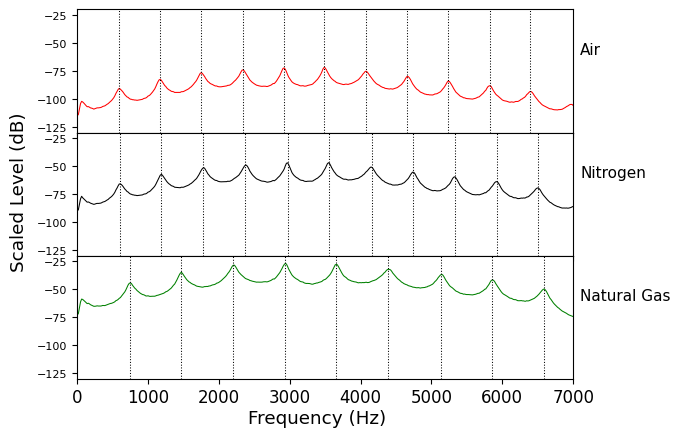

Figure 2: Plot showing each resonance node and its frequency in Hertz for air, nitrogen, and natural gas.
Data is presented side by side for easier comparison between the three gases.


In [ ]:
# Initializes a matplotlib subplot (plot all 4 gases and find_peak frequencies)
fig = plt.figure()
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True, sharey=True)

#Hide x labels and tick labels for all but bottom plot.
for ax in axs:
    ax.label_outer()

axs[0].plot(Air_Spectrum['Frequency (Hz)'], Air_Spectrum['Level (dB)']-45, 'red', label = 'Air')
axs[1].plot(Nitrogen_Spectrum['Frequency (Hz)'], Nitrogen_Spectrum['Level (dB)']-20, 'black', label = 'Nitrogen')
axs[2].plot(NG_Spectrum['Frequency (Hz)'], NG_Spectrum['Level (dB)'], 'green', label = 'Natural Gas')

#set the plotting axis limits and x- and y-axis labels
plt.axis([0,7000,-130,-20])
fig.supxlabel('Frequency (Hz)')
fig.supylabel('Scaled Level (dB)')

#For Loop to add the peak_list determined using SciPy find_peaks and add as verticle dotted lines to the spectrum plot
for y in range(len(Air_peak_list)):
  axs[0].axvline(x = Air_peak_list.iloc[y], color='k',linestyle='dotted')
for y in range(len(Nitrogen_peak_list)):
  axs[1].axvline(x = Nitrogen_peak_list.iloc[y], color='k',linestyle='dotted')
for y in range(len(NG_peak_list)):
  axs[2].axvline(x = NG_peak_list.iloc[y], color='k',linestyle='dotted')

#Annotate Plot with text
axs[0].text(7100, -60, 'Air', fontsize=11)
axs[1].text(7100, -60, 'Nitrogen', fontsize=11)
axs[2].text(7100, -60, 'Natural Gas', fontsize=11)

#Changing the Font Size Using rcParams
plt.rc('axes', labelsize=12)        # Controls Axes Labels
plt.rc('xtick', labelsize=12)       # Controls x Tick Labels
plt.rc('ytick', labelsize=8)       # Controls y Tick Labels
plt.rcParams['lines.linewidth'] = 0.75   # Controls linewidth for all Plots

#Show the plot in this notebook
plt.show()

print("Figure 2: Plot showing each resonance node and its frequency in Hertz for air, nitrogen, and natural gas.")
print("Data is presented side by side for easier comparison between the three gases.")

Fit and Plot the Combined Gas Resonance Frequency Data

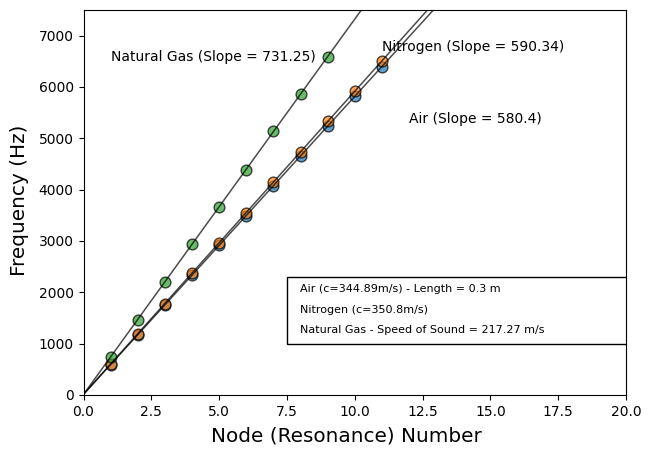

Figure 3: Node (resonance) number vs. frequency (Hz) for air, nitrogen, and natural gas.
Linear fit yields a slope of 580.4 for air, 590.34 for nitrogen, and 731.25 for natural gas.
The speed of sound was calculated to be 344.89 m/s for air, 350.8 m/s for nitrogen, and 217.27 m/s for natural gas.


In [ ]:
# Initialize plot layout
fig, ax = plt.subplots(figsize = (7, 5))

# Set general font size
plt.rcParams['font.size'] = '12'

# Set X and Y Axis Labels for subPlots
fig.supxlabel('Node (Resonance) Number')
fig.supylabel('Frequency (Hz)')

# Set tick font size
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
	label.set_fontsize(10)

# Add scatter plots
ax.scatter(Air_peaktable['Node'], Air_peaktable['Frequency (Hz)'], s=60, alpha=0.7, edgecolors="k")
ax.scatter(Nitrogen_peaktable['Node'], Nitrogen_peaktable['Frequency (Hz)'], s=60, alpha=0.7, edgecolors="k")
ax.scatter(NG_peaktable['Node'], NG_peaktable['Frequency (Hz)'], s=60, alpha=0.7, edgecolors="k")

# Fit linear regression via least squares with numpy.polyfit
# It returns an slope (b) and intercept (a)
# deg=1 means linear fit (i.e. polynomial of degree 1)
b1, a1 = np.polyfit(Air_peaktable['Node'], Air_peaktable['Frequency (Hz)'], deg=1)
b2, a2 = np.polyfit(Nitrogen_peaktable['Node'], Nitrogen_peaktable['Frequency (Hz)'], deg=1)
b3, a3 = np.polyfit(NG_peaktable['Node'], NG_peaktable['Frequency (Hz)'], deg=1)

c1_ref = 344.89 # Reference speed of sound for Air at 23 C

l1 = c1_ref/(2*b1)
c3 = ((l1)/2)*(2*b3)

# Calculate speed of sound for Air and Nitrogen from the measured slopes and calculated tube lengths
c_Air_measured = 2 * b1 * l1
c_Nitrogen_measured = 2 * b2 * l1

# Create sequence of 10 numbers from 298 to 365
xseq = np.linspace(0, 25, num=26)

# Plot regression line
ax.plot(xseq, a1 + b1 * xseq, alpha=0.7, color="k", lw=1.1)
ax.plot(xseq, a2 + b2 * xseq, alpha=0.7, color="k", lw=1.1)
ax.plot(xseq, a3 + b3 * xseq, alpha=0.7, color="k", lw=1.1)

ax.set_ylim(0, 7500)
ax.set_xlim(0,20)

#Annotate Plot with text
ax.text(12.0, 5300, 'Air (Slope = {})'.format(round(b1,2)), fontsize=10)
ax.text(11.0, 6700, 'Nitrogen (Slope = {})'.format(round(b2,2)), fontsize=10)
ax.text(1.0, 6500, 'Natural Gas (Slope = {})'.format(round(b3,2)), fontsize=10)

ax.text(8.0, 2000, 'Air (c={}m/s) - Length = {} m'.format(round(c_Air_measured,2), round(l1,2)), fontsize=8)
ax.text(8.0, 1600, 'Nitrogen (c={}m/s)'.format(round(c_Nitrogen_measured,2)), fontsize=8)
ax.text(8.0, 1200, 'Natural Gas - Speed of Sound = {} m/s'.format(round(c3,2)), fontsize=8)

# Create a Rectangle patch
rect = patches.Rectangle((7.5, 1000), 18, 1300, linewidth=1, edgecolor='k', facecolor='none')

# Add the patch to the Axes
ax.add_patch(rect)

#Show the plot in this notebook
plt.show()

print("Figure 3: Node (resonance) number vs. frequency (Hz) for air, nitrogen, and natural gas.")
print("Linear fit yields a slope of 580.4 for air, 590.34 for nitrogen, and 731.25 for natural gas.")
print(f"The speed of sound was calculated to be {round(c_Air_measured, 2)} m/s for air, {round(c_Nitrogen_measured, 2)} m/s for nitrogen, and {round(c3, 2)} m/s for natural gas.")

Error Analysis

In [ ]:
Air_linearregression = stats.linregress(Air_peaktable['Node'], Air_peaktable['Frequency (Hz)'])
Nitrogen_linearregression = stats.linregress(Nitrogen_peaktable['Node'], Nitrogen_peaktable['Frequency (Hz)'])
NG_linearregression = stats.linregress(NG_peaktable['Node'], NG_peaktable['Frequency (Hz)'])

print(f"Linear Regression R-squared")
print(f"Air - {Air_linearregression.rvalue**2:.6f}")
print(f"Nitrogen - {Nitrogen_linearregression.rvalue**2:.6f}")
print(f"Natural Gas - {NG_linearregression.rvalue**2:.6f}")
print(f"")

tinv = lambda p, df: abs(t.ppf(p/2, df))

print(f"95% Confidence Level (+/-)")
print(f"__________________________")
ts1 = tinv(0.05, len(Air_peaktable['Node'])-2)
print(f"Air")
print(f"slope = {Air_linearregression.slope:.2f} +/- {ts1*Air_linearregression.stderr:.2f}")
print(f"y-intercept = {Air_linearregression.intercept:.2f}"
      f" +/- {ts1*Air_linearregression.intercept_stderr:.2f}")
print(f" ")

ts2 = tinv(0.05, len(Nitrogen_peaktable['Node'])-2)
print(f"Nitrogen")
print(f"slope = {Nitrogen_linearregression.slope:.2f} +/- {ts1*Nitrogen_linearregression.stderr:.2f}")
print(f"y-intercept = {Nitrogen_linearregression.intercept:.2f}"
      f" +/- {ts1*Nitrogen_linearregression.intercept_stderr:.2f}")
print(f" ")

ts3 = tinv(0.05, len(NG_peaktable['Node'])-2)
print(f"Natural Gas")
print(f"slope = {NG_linearregression.slope:.2f} +/- {ts1*NG_linearregression.stderr:.2f}")
print(f"y-intercept = {NG_linearregression.intercept:.2f}"
      f" +/- {ts1*NG_linearregression.intercept_stderr:.2f}")
print(f" ")

c1_ref = 344.89 # Reference Speed of sound for Air
c1_ref_error = 1.74 # Error in reference speed of sound for Air

L = c1_ref / (2 * Air_linearregression.slope)

# Error propagation for Length (L = c_ref / (2 * slope))
# error_L = sqrt( (d(L)/d(c_ref)*error_c_ref)^2 + (d(L)/d(slope)*error_slope)^2 )
# d(L)/d(c_ref) = 1 / (2 * slope)
# d(L)/d(slope) = -c_ref / (2 * slope^2)
L_error = np.sqrt((abs(1 / (2 * Nitrogen_linearregression.slope)) * c1_ref_error)**2 + (abs(-c1_ref / (2 * Nitrogen_linearregression.slope**2)) * Nitrogen_linearregression.stderr)**2)


print(f"\nTube Length:")
print(f"  Air: {L:.2f} +/- {L_error:.2f} m")


# Calculate speed of sound for Air and Nitrogen using the slopes and the calculated tube length
c_Air_calculated = 2 * Air_linearregression.slope * L
c_Nitrogen_calculated = 2 * Nitrogen_linearregression.slope * L

# Error propagation for speed of sound (c = 2 * slope * L)
# error_c = sqrt( (d(c)/d(slope)*error_slope)^2 + (d(c)/d(L)*error_L)^2 )
# d(c)/d(slope) = 2 * L
# d(c)/d(L) = 2 * slope
c_Air_error_calculated = np.sqrt((2 * L * Air_linearregression.stderr)**2 + (2 * Air_linearregression.slope * L_error)**2)
c_Nitrogen_error_calculated = np.sqrt((2 * L * Nitrogen_linearregression.stderr)**2 + (2 * Nitrogen_linearregression.slope * L_error)**2)


print(f"\nCalculated Speed of Sound:")
print(f"  Air: {c_Air_calculated:.2f} +/- {c_Air_error_calculated:.2f} m/s")
print(f"  Nitrogen: {c_Nitrogen_calculated:.2f} +/- {c_Nitrogen_error_calculated:.2f} m/s")

# Calculate speed of sound for Natural Gas using its slope and the average tube length
c_NG_calculated = 2 * NG_linearregression.slope * L

# Error propagation for Natural Gas speed of sound (c_ng = 2 * slope_ng * L)
# error_c_ng = sqrt( (d(c_ng)/d(slope_ng)*error_slope_ng)^2 + (d(c_ng)/d(L)*error_L)^2 )
# d(c_ng)/d(slope_ng) = 2 * L
# d(c_ng)/d(L) = 2 * slope_ng
c_NG_error_calculated = np.sqrt((2 * L * NG_linearregression.stderr)**2 + (2 * NG_linearregression.slope * L_error)**2)

print(f"  Natural Gas: {c_NG_calculated:.2f} +/- {c_NG_error_calculated:.2f} m/s")

Linear Regression R-squared
Air - 0.999988
Nitrogen - 0.999991
Natural Gas - 0.999988

95% Confidence Level (+/-)
__________________________
Air
slope = 580.40 +/- 1.53
y-intercept = 13.36 +/- 10.37
 
Nitrogen
slope = 590.34 +/- 1.37
y-intercept = 13.35 +/- 9.30
 
Natural Gas
slope = 731.25 +/- 2.18
y-intercept = 10.41 +/- 12.28
 

Tube Length:
  Air: 0.30 +/- 0.00 m

Calculated Speed of Sound:
  Air: 344.89 +/- 1.79 m/s
  Nitrogen: 350.80 +/- 1.81 m/s
  Natural Gas: 434.53 +/- 2.27 m/s


Calculation of Thermodynamic Properties

In [ ]:
# Known values
T = 296.65  # K, lab temp
T_error = 2 # K, lab temp error
R = 8.314  # J/mol/K
M_NG = 0.01604  # kg/mol (Methane, based on speed of sound at 295.15 K)
M_Air = 0.02896 # kg/mol (Air)
M_Nitrogen = 0.028 # kg/mol (Nitrogen)

# Get the calculated tube length and its error from the previous cell
L = L
L_error = L_error

# Get the slopes and their errors from the linear regression in the previous cell
Air_linearregression = stats.linregress(Air_peaktable['Node'], Air_peaktable['Frequency (Hz)'])
Nitrogen_linearregression = stats.linregress(Nitrogen_peaktable['Node'], Nitrogen_peaktable['Frequency (Hz)'])
NG_linearregression = stats.linregress(NG_peaktable['Node'], NG_peaktable['Frequency (Hz)'])

b1 = Air_linearregression.slope
b1_error = Air_linearregression.stderr

b2 = Nitrogen_linearregression.slope
b2_error = Nitrogen_linearregression.stderr

b3 = NG_linearregression.slope
b3_error = NG_linearregression.stderr

# Calculate speeds of sound using the slopes and the calculated tube length
c_Air = 2 * b1 * L
c_Nitrogen = 2 * b2 * L
c_NG = 2 * b3 * L

# Error propagation for speed of sound (c = 2 * slope * L)
# error_c = sqrt( (d(c)/d(slope)*error_slope)^2 + (d(c)/d(L)*error_L)^2 )
# d(c)/d(slope) = 2 * L
# d(c)/d(L) = 2 * slope
c_Air_error = np.sqrt((2 * L * b1_error)**2 + (2 * b1 * L_error)**2)
c_Nitrogen_error = np.sqrt((2 * L * b2_error)**2 + (2 * b2 * L_error)**2)
c_NG_error = np.sqrt((2 * L * b3_error)**2 + (2 * b3 * L_error)**2)

# Gamma for Natural Gas
gamma_NG = (c_NG**2 * M_NG) / (R * T)

# Error propagation for gamma_NG
# gamma = (c^2 * M) / (R * T)
# d(gamma)/dc = (2 * c * M) / (R * T)
# d(gamma)/dT = -(c^2 * M) / (R * T^2)
# error_gamma = sqrt( (d(gamma)/dc*error_c)^2 + (d(gamma)/dT*error_T)^2 )
gamma_NG_error = np.sqrt((abs((2 * c_NG * M_NG) / (R * T)) * c_NG_error)**2 + (abs(-(c_NG**2 * M_NG) / (R * T**2)) * T_error)**2)

# Heat capacities for Natural Gas
Cv_NG = R / (gamma_NG - 1)
Cp_NG = Cv_NG + R

# Error propagation for Cv_NG
# Cv = R / (gamma - 1)
# d(Cv)/d(gamma) = -R / (gamma - 1)^2
# error_Cv = |d(Cv)/d(gamma)| * error_gamma
Cv_NG_error = abs(-R / (gamma_NG - 1)**2) * gamma_NG_error

# Error propagation for Cp_NG
# Cp = Cv + R
# d(Cp)/d(Cv) = 1
# error_Cp = |d(Cp)/d(Cv)| * error_Cv
Cp_NG_error = Cv_NG_error

print(f"Natural Gas (methane):")
print(f"  Speed of sound (c): {c_NG:.2f} +/- {c_NG_error:.2f} m/s")
print(f"  Adiabatic Index (gamma): {gamma_NG:.3f} +/- {gamma_NG_error:.3f}")
print(f"  Cv: {Cv_NG:.2f} +/- {Cv_NG_error:.2f} J/mol·K")
print(f"  Cp: {Cp_NG:.2f} +/- {Cp_NG_error:.2f} J/mol·K")

# Gamma for Air
gamma_Air = (c_Air**2 * M_Air) / (R * T)

# Error propagation for gamma_Air
gamma_Air_error = np.sqrt((abs((2 * c_Air * M_Air) / (R * T)) * c_Air_error)**2 + (abs(-(c_Air**2 * M_Air) / (R * T**2)) * T_error)**2)

# Heat capacities for Air
Cv_Air = R / (gamma_Air - 1)
Cp_Air = Cv_Air + R

# Error propagation for Cv_Air
Cv_Air_error = abs(-R / (gamma_Air - 1)**2) * gamma_Air_error

# Error propagation for Cp_Air
Cp_Air_error = Cv_Air_error

print(f"\nAir:")
print(f"  Speed of sound (c): {c_Air:.2f} +/- {c_Air_error:.2f} m/s")
print(f"  Adiabatic Index (gamma): {gamma_Air:.3f} +/- {gamma_Air_error:.3f}")
print(f"  Cv: {Cv_Air:.2f} +/- {Cv_Air_error:.2f} J/mol·K")
print(f"  Cp: {Cp_Air:.2f} +/- {Cp_Air_error:.2f} J/mol·K")

# Gamma for Nitrogen
gamma_Nitrogen = (c_Nitrogen**2 * M_Nitrogen) / (R * T)

# Error propagation for gamma_Nitrogen
gamma_Nitrogen_error = np.sqrt((abs((2 * c_Nitrogen * M_Nitrogen) / (R * T)) * c_Nitrogen_error)**2 + (abs(-(c_Nitrogen**2 * M_Nitrogen) / (R * T**2)) * T_error)**2)

# Heat capacities for Nitrogen
Cv_Nitrogen = R / (gamma_Nitrogen - 1)
Cp_Nitrogen = Cv_Nitrogen + R

# Error propagation for Cv_Nitrogen
Cv_Nitrogen_error = abs(-R / (gamma_Nitrogen - 1)**2) * gamma_Nitrogen_error

# Error propagation for Cp_Nitrogen
Cp_Nitrogen_error = Cv_Nitrogen_error

print(f"\nNitrogen:")
print(f"  Speed of sound (c): {c_Nitrogen:.2f} +/- {c_Nitrogen_error:.2f} m/s")
print(f"  Adiabatic Index (gamma): {gamma_Nitrogen:.3f} +/- {gamma_Nitrogen_error:.3f}")
print(f"  Cv: {Cv_Nitrogen:.2f} +/- {Cv_Nitrogen_error:.2f} J/mol·K")
print(f"  Cp: {Cp_Nitrogen:.2f} +/- {Cp_Nitrogen_error:.2f} J/mol·K")

Natural Gas (methane):
  Speed of sound (c): 434.53 +/- 2.27 m/s
  Adiabatic Index (gamma): 1.228 +/- 0.015
  Cv: 36.47 +/- 2.44 J/mol·K
  Cp: 44.78 +/- 2.44 J/mol·K

Air:
  Speed of sound (c): 344.89 +/- 1.79 m/s
  Adiabatic Index (gamma): 1.397 +/- 0.017
  Cv: 20.96 +/- 0.91 J/mol·K
  Cp: 29.27 +/- 0.91 J/mol·K

Nitrogen:
  Speed of sound (c): 350.80 +/- 1.81 m/s
  Adiabatic Index (gamma): 1.397 +/- 0.017
  Cv: 20.94 +/- 0.91 J/mol·K
  Cp: 29.25 +/- 0.91 J/mol·K


# **Discussion**

Nitrogen behaved as expected of a diatomic gas, with a speed of sound **c = 350.80 ± 1.81 m/s** at 23° C, or 296 K. This value closely matched the literature value of **350.89 m/s** <sup>[9]</sup>. The experimental values for Cv (**20.94 ± 0.91 J/mol·K**) and Cp (**29.25 ± 0.91 J/mol·K**) also closely matched the literature values of Cv (**20.817 J/mol·K**) and Cp (**29.172 J/mol·K**) <sup>[9]</sup>.

<img src="https://raw.githubusercontent.com/sraymundo15/sraymundo15/d65cc39dc9834219c05b851982946ca10a51d582/01_Nitrogen_Gas_Molecular_Structure.png" width="250" alt="Molecular Structure of Nitrogen" />

*<sub>Molecular representation of nitrogen gas as obtained from MolCalc</sub>*

Air behaved as expected of a mixture of gases, with its main component being diatomic nitrogen. Its speed of sound **c = 344.89 ± 1.79 m/s** at 23° C, or 296 K. This value closely matched both the experimental and literature values of nitrogen as seen above. The experimental values for Cv (**20.96 ± 0.91 J/mol·K**) and Cp (**29.27 ± 0.91 J/mol·K**) also closely matched the respective values of nitrogen. The differences in all these values can be explained by the presence of other trace gases that would allow for increased heat capacity due to translational, rotational, and vibrational effects. This would increase the adiabatic index of air while decreasing the speed of sound in air at the same time.

Finally, although the experimental natural gas was assumed to be pure methane, comparing the calculated results against the literature values of pure methane showed significant differences. The speed of sound of natural gas was calculated to be **c = 434.53 ± 2.27 m/s** at 23° C, or 296 K, while the literature value was **447.09 m/s** <sup>[11]</sup>. The experimental values for Cv (**36.47 ± 2.44 J/mol·K**) and Cp (**44.78 ± 2.44 J/mol·K**) also differed from the literature values of Cv (**27.337 J/mol·K**) and Cp (**35.730 J/mol·K**) <sup>[11]</sup>. When comparing the differences between natural gas and the literature values for methane with the previously stated differences between nitrogen and air, it can be assumed that the natural gas used for this experiment was a mixture of gases. While the majority of the natural gas is methane <sup>[12]</sup>, the presence of other gases causes the differences in speed of sound, Cv, and Cp between natural gas and pure methane.  

<img src="https://raw.githubusercontent.com/sraymundo15/sraymundo15/d65cc39dc9834219c05b851982946ca10a51d582/01_Methane_Molecular_Structure.png" width="250" alt="Molecular Structure of Methane" />

*<sub>Molecular representation of methane as obtained from MolCalc</sub>*

# **Acknowledgements**

I would like to thank Prof. Jeff Yarger (jyarger@proton.me) for making available a [CoLab notebook](https://github.com/CHM343/Acoustic_Interferometer/blob/main/Notebooks/Remote_Acoustic_Interferometer_Data_Analysis_2023.ipynb) with detailed analysis and error propagation of acoustic interferometry data, which I used as a template and starting point for writing this notebook.

Additionally, I would like to thank my classmate, Candace Schwartz (cschwa17@asu.edu), who submitted an initial draft of her CoLab notebook report to Slack, which allowed me to review my code against hers and debug issues I was facing when plotting spectral data, as well as benefit from the feedback Prof. Yarger gave her.

Additional thanks to all of my classmates' comments and questions, as well as Prof. Yarger for his feedback and answers on the Slack group. The input in the Slack group proved valuable in understanding and improving each draft of this notebook.

AI tools were used to complement the writing of this notebook. Gemini helped to explain and correct the code needed for accurately calculating each of the required quantities in this report. ChatGPT and Grok were used to find crucial keywords needed for successfully finding appropriate resources for reference, as well as providing additional clarification and syntax correction for snippets of code when Gemini was unclear or unhelpful.

All data was obtained by myself on September 1st, 2025 and is publicly available on my [Github repository](https://github.com/sraymundo15/sraymundo15).

# **References**

[1] Yarger, J. L. Relation of Sound Speed to Thermodynamic Properties of Gases. Physical Chemistry Cloud Laboratory on Vimeo. https://vimeo.com/showcase/11848054 (accessed 2025-09-05).

[2] Varberg, T. D.; Pearlman, B. W.; Wyse, I. A.; Gleason, S. P.; Kellett, D. H. P.; Moffett, K. L. Determining the Speed of Sound and Heat Capacity Ratios of Gases by Acoustic Interferometry. J. Chem. Educ. 2017, 94 (12), 1995–1998. https://doi.org/10.1021/acs.jchemed.7b00526 (accessed 2025-09-05).

[3] DeLomba, M. J.; Hernandez, M. D.; Stankus, J. J. Speed of Sound in Gases Measured by in Situ Generated White Noise. Journal of Chemical Education 2016, 93 (11), 1961–1964. https://doi.org/10.1021/acs.jchemed.6b00407 (accessed 2025-09-05).

[4] Yarger, J. Acoustic Interferometry Pchem ‘Cloud’ Lab – Properties of Gases. BioPchem. https://biopchem.education/2022/01/17/acoustic-interferometry-pchem-cloud-lab/ (accessed 2025-09-03).

[5] Lowengrub, D. Heat Capacity and the Speed of Sound. www.daniellowengrub.com. https://www.daniellowengrub.com/blog/2020/12/19/heat-capacity-sound (accessed 2025-09-03).

[6] Crim, F. F. (2008). Chemical Dynamics of vibrationally excited molecules: Controlling reactions in gases and on surfaces. Proceedings of the National Academy of Sciences, 105(35), 12654–12661. https://doi.org/10.1073/pnas.0803010105 (accessed 2025-09-09)

[7] Yarger, J. Determining the Speed of Sound and Related Heat Capacity Ratios of Gases Using Acoustic Interferometry and Molecular Electronic Structure Calculations a Physical Chemistry Cloud Laboratory. https://biopchem.education/wp-content/uploads/2025/08/lab1_handout_chm343_fall2025.pdf (accessed 2025-09-03).

[8] Jensen, J.H. Nitrogen Thermodynamic Properties. *Molecular Calculator (MolCalc).* https://molcalc.org/calculations/7133e8261161db19f61450c7e662988d (accessed 2025-09-09).

[9] NIST Webbook. Isobaric Properties for Nitrogen. https://webbook.nist.gov/cgi/fluid.cgi?P=1&TLow=23&THigh=23&TInc=&Digits=5&ID=C7727379&Action=Load&Type=IsoBar&TUnit=C&PUnit=atm&DUnit=mol%2Fl&HUnit=kJ%2Fmol&WUnit=m%2Fs&VisUnit=uPa*s&STUnit=N%2Fm&RefState=DEF (accessed 2025-09-09).

[10] Jensen, J.H. Methane Thermodynamic Properties. *Molecular Calculator (MolCalc).* https://molcalc.org/calculations/559ef0dd7353b6674f78dfd22bc169be (accessed 2025-09-09).

[11] NIST Webbook. Isobaric Properties for Methane. https://webbook.nist.gov/cgi/fluid.cgi?P=1&TLow=23&THigh=23&TInc=&Digits=5&ID=C74828&Action=Load&Type=IsoBar&TUnit=C&PUnit=atm&DUnit=mol%2Fl&HUnit=kJ%2Fmol&WUnit=m%2Fs&VisUnit=uPa*s&STUnit=N%2Fm&RefState=DEF (accessed 2025-09-09).

[12] Faramawy, S.; Zaki, T.; Sakr, A. A.-E. Natural Gas Origin, Composition, and Processing: A Review. Journal of Natural Gas Science and Engineering 2016, 34, 34–54. https://doi.org/10.1016/j.jngse.2016.06.030. (accessed 2025-09-10)

